# Fleet Census: the GB battery population, and how much of it each tier sees

**What this notebook is for.** Two things, in that order. It **reconstructs the population** —
every BM-registered GB battery site — because nobody publishes the list and notebooks 04 and 05
need one before "the fleet discharges into stress" can mean anything more than "our sample
does". Then it **measures the curated `fleet.registry` cross-section against that population**,
because the dashboard's population is drawn from it and a reader is owed the size of the
sample they are looking at.

**Which population each tier has.** Three populations come out of this notebook's census, and
they are not a full version and two cut-downs of it. Each answers a different question:

| Tier | Population | Why that one |
|---|---|---|
| Research notebooks 04, 05 | The **87-site census** built here — `fleet.population.census_population()` | A claim about *the GB fleet* needs the fleet, not a cross-section of it |
| Live dashboard | **65 sites, 99 BM Units, 5,559 MW** — `fleet.registry.REGISTRY`, the census sites whose energy capacity is known | Cycles per day and the duration bucket both divide by MWh, so a site without one renders blank cells rather than smaller numbers |

`fleet.registry` still exists, but not as a tier: it is the hand-verified optimiser and region
metadata for 23 of the 65 sites the dashboard renders, and the seed the generator checks its
output against. Nothing is reported on it, and no percentage below is a share of it.

**So read the coverage figure correctly.** It is **not** a discount to apply to this project's
fleet results — the research tier has the whole census. It is the measured size of what the
dashboard renders, and the reason the dashboard states it on the page.

**Why reconstruction takes work.** Elexon's BM Unit reference — the only per-unit feed this
project can settle against — labels no unit as a battery: 2,473 of 3,060 units carry no fuel
type at all, and not one row says "battery". So the population has to be *reconstructed* from
what several public registers agree on, which is what `fleet.census` does and what section 1
audits before any percentage is quoted.

**Method.** The four tiers of the coverage brief, one per section:

| § | Tier | What it establishes |
|---|---|---|
| 2 | Coverage assessment | Every known battery, and what is known about it |
| 3 | Representativeness | What the dashboard renders, by site count, by MW, by MWh |
| 4 | Characterising the gap | How the sites it cannot show differ from the ones it can |
| 5 | A persistent asset ID | So the answer survives owner, name and BMU changes |

Sections 6 to 8 then test the one tuned number the rule contains, price the revenue stack the
per-unit feeds can and cannot see, and state the claim the whole exercise exists to produce.

**The analysis is frozen at 2026-08-23, and that is a decision with a cost.** The five
registers behind the census and NESO's auction results are all live, so two runs on different
days return a different population *and* different revenue, and every figure quoting either
disagrees with the next run. `fleet.census.DATA_SNAPSHOT` fixes both at **2026-08-23**, which
is the snapshot every committed result here is computed on. It should be
moved forward to take the census live again — the fleet is still growing and a held snapshot
understates it — but moving it means re-running notebooks 04, 05 and 06, regenerating
`fleet/registry.py`, and updating the counts in the README, the poster and the architecture
docs. The constant's docstring carries that checklist.

**Scope, stated once.** The denominator is *BM-registered* batteries. Assets traded behind an
aggregator, VLP or supplier portfolio are physically real but have no per-unit Elexon feed, so
they can be neither dispatch-analysed nor counted here. Every percentage below is a share of
the BM-registered fleet, not of GB storage — and sections 5 and 7 size what that leaves out.


In [1]:
%matplotlib inline

import datetime as dt
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.utils.poster import save_poster_fig

from fleet import ancillary, census, coverage
from fleet.curated import CURATED_SITES
from fleet.registry import REGISTRY

# ── Frozen vintage ──────────────────────────────────────────────────────────
# The registers behind the census and NESO's auction results are both live, so
# an unpinned run returns a different population and different revenue every
# day, and every number below moves with it. This notebook fixes both at
# 2026-08-24 — the same date notebooks 04, 05 and 06 all use, so the three are
# directly comparable. The library default is unpinned; this is a notebook
# decision, set here rather than in the repo.
#
# To move the analysis on: change this date, re-run, and update any figure of
# this notebook's that README.md, DATA_ARCHITECTURE.md or the poster quote.
census.SNAPSHOT = dt.date(2026, 8, 24)

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

# Same design system as notebooks 04 and 05. The split used throughout this
# notebook is "what the dashboard can render" against "what it cannot" — both
# real quantities, so both get a real colour rather than one fading into grey.
C = {
    "ink":       "#0b0b0b",
    "covered":   "#2a78d6",
    "covered_lo": "#8fb9e8",
    "gap":       "#e34948",
    "discharge": "#1baf7a",
    "mid":       "#c98500",
    "ghost":     "#c3c2b7",
}

# The census is a July-2026 snapshot — a register of what exists now — but the
# revenue section in part 7 reaches back as far as NESO published per-unit
# results, which is further than the dispatch window. Starting it at 2018 shows
# the whole of what is obtainable, including the years that are simply absent.
ANALYSIS_START = dt.date(2018, 1, 1)
ANALYSIS_END = dt.date(2026, 8, 24)

## 1. Building the census — and auditing it before trusting it

Five public sources, each cached once per day. Elexon's BM Unit reference supplies the
population to classify; the NESO Capacity Market register supplies explicit `Storage`
technology *with duration*, which is the only free source that yields **MWh** rather than MW
alone; the TEC and Embedded connection registers supply built storage projects and their
connection dates; the response-auction results supply an explicit `Batteries` technology type
per participant.

**The identifying rule.** Four necessary conditions, all read off Elexon's own reference data:
the unit is physical (not a supplier portfolio or interconnector), carries no conflicting fuel
label, declares both import and export capability, and declares them **symmetrically**.

That last condition is what makes the rule precise rather than merely plausible. A battery's
charge and discharge ratings are near-symmetric by construction. A generator with a site load
looks bidirectional but is nowhere near symmetric. The cell below plots the two populations
so the separation can be seen rather than asserted.

In [2]:
units = census.battery_bmus()

known = units[units["sig_registry"]]
print(f"BMU population              {len(units):,}")
print(f"units with no fuel type     {int(units['fuelType'].isna().sum()):,}")
print(f"classified as batteries     {int(units['is_battery'].sum()):,}")
print()
print("Recall check — the curated registry is ground truth the rule never sees:")
print(f"  registry BM Units          {len(known)}")
print(f"  recovered by the rule      {int((known['is_physical'] & known['fuel_permits_battery'] & known['is_bidirectional'] & known['is_symmetric']).sum())}")
print()
print("Confidence of the classified population:")
print(units.loc[units["is_battery"], "confidence"].value_counts().to_string())

BMU population              3,055
units with no fuel type     2,470
classified as batteries     127

Recall check — the curated registry is ground truth the rule never sees:
  registry BM Units          47
  recovered by the rule      47

Confidence of the classified population:
confidence
corroborated      77
registry          47
signature_only     3


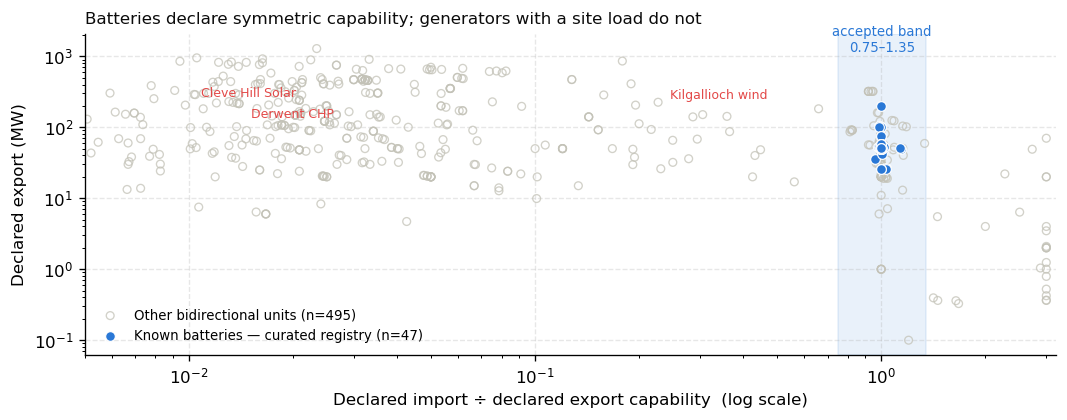

In [3]:
# Figure 1 — the symmetry test, and why it separates cleanly.
bidir = units[units["is_bidirectional"] & units["is_physical"]].copy()
bidir["ratio"] = bidir["capability_ratio"].clip(upper=3.0)

fig, ax = plt.subplots(figsize=(9, 3.6))
lo, hi = census.SYMMETRY_BAND
ax.axvspan(lo, hi, color=C["covered"], alpha=0.10, zorder=0)

rest = bidir[~bidir["sig_registry"]]
ax.scatter(rest["ratio"], rest["generationCapacity"], s=22, facecolor="none",
           edgecolor=C["ghost"], linewidth=0.8, alpha=0.75,
           label=f"Other bidirectional units (n={len(rest)})", zorder=2)
ax.scatter(known["capability_ratio"].clip(upper=3.0), known["generationCapacity"], s=34,
           color=C["covered"], edgecolor="white", linewidth=0.7,
           label=f"Known batteries — curated registry (n={len(known)})", zorder=3)

# Offsets are set individually: these three sit close together and default
# placement overlaps them.
for label, x, y, off in [("Cleve Hill Solar", 0.010, 205.0, (7, 5)),
                         ("Derwent CHP", 0.014, 218.0, (7, -9)),
                         ("Kilgallioch wind", 0.227, 225.0, (7, 2))]:
    ax.annotate(label, (x, y), fontsize=7.5, color=C["gap"],
                xytext=off, textcoords="offset points")

ax.set_xscale("log")
# Log on both axes: the background population spans 1-1200 MW, and on a linear
# scale the batteries all pile into the bottom eighth of the panel.
ax.set_yscale("log")
ax.set_xlim(0.005, 3.2)
ax.set_xlabel("Declared import ÷ declared export capability  (log scale)")
ax.set_ylabel("Declared export (MW)")
ax.set_title("Batteries declare symmetric capability; generators with a site load do not",
             fontsize=10, loc="left", color=C["ink"])
ax.annotate(f"accepted band\n{lo}–{hi}", (np.sqrt(lo * hi), ax.get_ylim()[1] * 0.55),
            ha="center", fontsize=8, color=C["covered"])
ax.legend(frameon=False, fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

## 2. The census, and what it contains

`coverage.coverage_table()` returns one row per identified battery site: its BM Units, its
declared MW, its energy capacity where anyone publishes one, and whether the curated registry
contains it — and if not, why. The reason carries more weight than the count. A site missing
because it is 12 MW is a scope decision the registry states up front; a site missing because
nobody added it is the real gap, and section 4 hands a reviewer that second number.

`missing_reason` is a legacy column: it records why a site is outside `fleet.registry`, the
hand-curated seed, which nothing is reported on any more. What matters from here is whether a
site's **energy capacity is published**, because that is the rule the dashboard's population is
drawn on, and the cell after next marks it on the table.

**This is the population notebooks 04 and 05 run on**, so its own shape — not its overlap with
the registry — is what a reader needs first. The figure at the end of this section draws it with
no registry split at all; that comparison is a separate question, and it starts in section 3.


In [4]:
table = coverage.coverage_table()

print(f"census sites: {len(table)}   BM Units: {int(table['n_bmus'].sum())}   "
      f"declared MW: {table['declared_export_mw'].sum():,.0f}\n")
print(table["missing_reason"].fillna("in the registry").value_counts().to_string())
print()
print(f"energy capacity known for {int(table['capacity_mwh'].notna().sum())} of {len(table)} sites",
      dict(table["mwh_source"].value_counts()))

Worksheet row for GB-BESS-WOLVB (Wolverhampton West BESS) needs review: 310 MWh over 56.0 MW declared implies 5.5 h, longer than any priced census site. Self-consistent with the duration recorded, so the agreement check cannot judge it — confirm the figure covers this BM Unit and not the wider project.


census sites: 87   BM Units: 124   declared MW: 6,234

missing_reason
not curated         45
in the registry     23
below size floor    19

energy capacity known for 65 of 87 sites {'corporate': np.int64(24), 'registry': np.int64(23), 'capacity_market': np.int64(18)}


In [5]:
# Two routes to the same units, stated as a number rather than a claim.
#
# `fleet.curated` is a hand-researched metadata table, assembled by naming
# operators and cross-checking capacities against Elexon. The symmetry rule
# knows none of that — it reads declared import against declared export. That
# the two agree is corroboration between methods.
#
# It is deliberately *not* called validation against ground truth: the curated
# table is itself a fallible artefact, and nothing here establishes that its
# sites are batteries independently of the rule. Agreement is evidence; it is
# not proof, and the rule is no longer given the list as a shortcut — the
# classifier admits units on the signature alone.
curated_units = {b for s in CURATED_SITES for b in s.bmu_ids}
found = set(table["bmu_ids"].explode().dropna())
recovered = curated_units & found
print(f"Method agreement: {len(units):,} BM Units screened; the rule admits "
      f"{len(recovered)}/{len(curated_units)} of the hand-researched BM Units "
      f"unaided, and {len(table)} sites in total "
      f"({int(table['declared_export_mw'].sum()):,} MW), every one corroborated "
      f"by a second public register.")


Method agreement: 3,055 BM Units screened; the rule admits 47/47 of the hand-researched BM Units unaided, and 87 sites in total (6,234 MW), every one corroborated by a second public register.


In [6]:
# Which tier renders which sites.
#
# `fleet.registry` is the fleet this project analyses — generated from this
# census, and the population the live dashboard imports and renders. Marking
# census rows against it measures what actually reaches a page.
_reg_bmus = set(REGISTRY.bmu_ids())
table["in_dashboard"] = table["bmu_ids"].apply(lambda b: bool(set(b) & _reg_bmus))

# The dashboard's population is exactly the known-MWh subset, by construction:
# its generator drops sites whose cycles and duration bucket would be blank.
# Asserted rather than assumed, so a change to that rule stops here loudly
# instead of quietly making the funnel below wrong.
assert (table["in_dashboard"] == table["capacity_mwh"].notna()).all(), \
    "fleet.registry is no longer the known-MWh subset — the funnel needs a fourth stage"
assert not (table["in_registry"] & ~table["in_dashboard"]).any(), \
    "fleet.registry is no longer a superset of the curated metadata table"

census_mw = table["declared_export_mw"].sum()
table["n_units"] = table["bmu_ids"].map(len)


def _tier_line(label: str, rows) -> str:
    mw = rows["declared_export_mw"].sum()
    return (f"{label:<15} {len(rows):>3} sites  {int(rows['n_units'].sum()):>4} BM Units  "
            f"{mw:>7,.0f} MW  {100 * mw / census_mw:>5.1f}% of census MW")


print(_tier_line("live dashboard", table[table["in_dashboard"]]))
print(_tier_line("census", table))

# `fleet.registry` is generated from the census but carries `fleet.curated`'s
# hand-researched metadata, so a BM Unit that table omits at a site it already
# lists is one nothing renders either. Printed rather than reconciled silently:
# it is a real gap with a one-line fix.
listed = {b for s in CURATED_SITES for b in s.bmu_ids}
found = set(table.loc[table["in_registry"], "bmu_ids"].explode())
if found - listed:
    print(f"\nfleet.curated lists {len(listed)} BM Units at the sites it covers; the census "
          f"finds {len(found)}. {', '.join(sorted(found - listed))} are registered to one of "
          f"those sites but missing from curated.py, so nothing renders them.")


live dashboard   65 sites    99 BM Units    5,559 MW   89.2% of census MW
census           87 sites   124 BM Units    6,234 MW  100.0% of census MW

fleet.curated lists 47 BM Units at the sites it covers; the census finds 49. E_BURWB-2, E_BURWB-3 are registered to one of those sites but missing from curated.py, so nothing renders them.


In [7]:
gaps = coverage.gap_characterisation(table)


# `coverage.gap_characterisation` measures the curated registry, which is the
# metadata baseline rather than what the dashboard renders. The dashboard's own
# coverage is added here rather than in `fleet.coverage`, because that module is
# barred from the dashboard's process and this is a research-tier question.
def with_dashboard(frame: pd.DataFrame, key: str) -> pd.DataFrame:
    grouped = table.groupby(key)
    frame = frame.copy()
    frame["sites_in_dashboard"] = grouped["in_dashboard"].sum()
    frame["mw_in_dashboard"] = grouped.apply(
        lambda g: g.loc[g["in_dashboard"], "declared_export_mw"].sum(),
        include_groups=False,
    )
    frame["dashboard_pct"] = (100.0 * frame["mw_in_dashboard"] / frame["mw"]).round(1)
    return frame


# Bands in nameplate order rather than the frame's own descending-MW order:
# both figures below read down this axis, and a band out of sequence reads as
# a data error rather than a sort.
size_order = [f"{lo}-{hi} MW" if hi < 10_000 else f"{lo}+ MW"
              for lo, hi in coverage.SIZE_BANDS]
by_size = with_dashboard(gaps["size_band"].reindex(size_order).dropna(how="all"), "size_band")
by_conn = with_dashboard(gaps["connection_level"], "connection_level")

by_size[["sites", "sites_in_dashboard", "mw", "mw_in_dashboard", "dashboard_pct"]]


,sites,sites_in_dashboard,mw,mw_in_dashboard,dashboard_pct
size_band,,,,,
0-20 MW,7,1,46.1,7.120,15.4
20-50 MW,33,18,1202.0,617.874,51.4
50-100 MW,31,30,1826.9,1774.934,97.2
100-200 MW,9,9,1075.6,1075.613,100.0
200+ MW,7,7,2083.8,2083.783,100.0


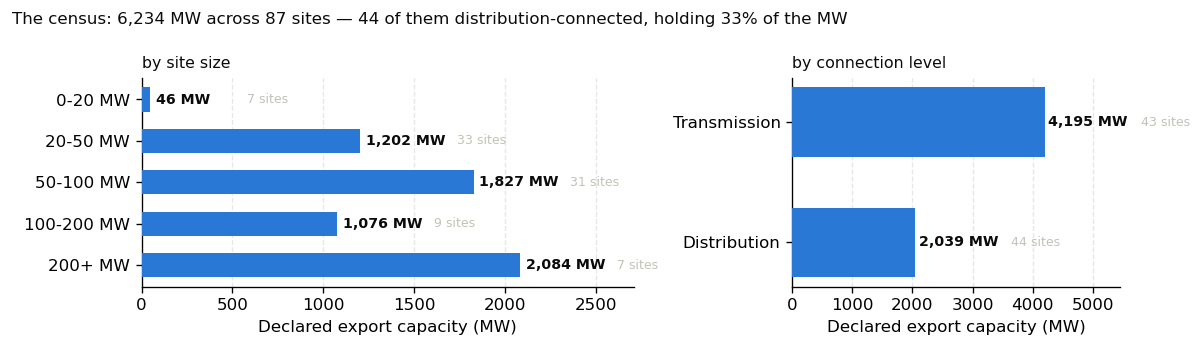

In [8]:
# Figure 2 — what the census contains, before any question of who covers it.
# The poster leads with this: sections 3 to 5 all analyse this population, so
# the fleet's own shape is the thing a reader needs first. No registry split
# here on purpose — that comparison is a separate question, asked from the
# next section on. `by_size` / `by_conn` come from the cell above.
fig, axes = plt.subplots(1, 2, figsize=(10, 2.9),
                         gridspec_kw={"width_ratios": [3, 2]})

for ax, frame, title in (
    (axes[0], by_size, "by site size"),
    (axes[1], by_conn, "by connection level"),
):
    y = np.arange(len(frame))
    mw = frame["mw"].to_numpy()
    # One measure, one hue. Site count rides as a label rather than a second
    # bar, because two bars on one axis invite reading them as a ratio.
    ax.barh(y, mw, height=0.58, color=C["covered"], zorder=3)
    for i, (val, n) in enumerate(zip(mw, frame["sites"])):
        # One line rather than two stacked: a second line either collides with
        # the bar above or clips the top spine on the first bar.
        ax.text(val + frame["mw"].max() * 0.015, i,
                f"{val:,.0f} MW", va="center", fontsize=8.5,
                color=C["ink"], fontweight="bold")
        ax.annotate(f"{n} sites", (val, i), xytext=(58, 0),
                    textcoords="offset points", va="center",
                    fontsize=7.5, color=C["ghost"])
    ax.set_yticks(y, frame.index)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("Declared export capacity (MW)")
    ax.set_xlim(0, frame["mw"].max() * 1.30)
    ax.set_title(title, fontsize=9.5, loc="left", color=C["ink"])

# Titled from the frames rather than from a previous run's numbers: the public
# registers refresh between runs, and a hardcoded total goes stale silently.
total_mw = table["declared_export_mw"].sum()
dist = by_conn.loc["Distribution"]
fig.suptitle(
    f"The census: {total_mw:,.0f} MW across {len(table)} sites — "
    f"{dist['sites']:.0f} of them distribution-connected, holding "
    f"{dist['mw'] / total_mw:.0%} of the MW",
    fontsize=10, x=0.005, ha="left", color=C["ink"])
plt.tight_layout()
# Print-resolution export for the poster: the fleet's own composition. The
# export name keeps the poster's numbering (it leads with this as Fig 1), which
# is what reports/poster/poster.typ references — renaming it breaks the poster.
save_poster_fig(fig, "nb06_fig1_census_composition")

plt.show()


## 3. How much of that population does the dashboard render?

For notebooks 04 and 05 the answer is *all of it* — they take the census as their population.
The question binds the **live dashboard**, which renders the 65 census sites whose energy
capacity is published, and every figure quoted from it.

The funnel below states the attrition once, so no later claim has to carry its own
denominator. Coverage then follows on three bases, because they disagree and the disagreement
is informative.

**Site count flatters nothing here** — it is the *lowest* of the three, because published
duration correlates with size. **MW is the headline**: it is what fleet response, headroom and
availability are all measured in. **MWh is the most useful and the least available** — duration
is published only through Capacity Market agreements and hand-researched operator pages, and
where it is missing the dashboard cannot render the site at all. That last point is why the MWh
row reads 100% and means something narrower than it looks: it covers all of the energy capacity
*that is known*, not all of the energy capacity that exists.


COVERAGE FUNNEL
  Sites admitted to the census — notebooks 04, 05   87  (100%)
  Energy capacity known — the live dashboard        65  ( 75%)


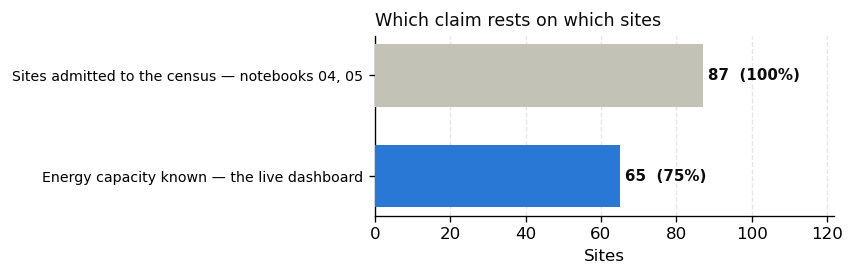

In [9]:
# Figure 3 — a coverage funnel: which claim applies to which population.
#
# The poster makes four different claims about four different subsets, and a
# reader is entitled to ask which sites each one rests on. This states the
# attrition once, in order, so no claim has to carry its own denominator.
# Only stages that actually attrit. Corroboration is not one of them: the
# census admits corroborated grades by construction, so a "corroborated"
# row would read 100% and tell the reader nothing.
# Every stage is in sites. The BM Unit screening count is in the audit line of
# section 2, not on a shared percentage axis with site counts.
#
# Two stages, not three: the dashboard's population *is* the known-MWh subset,
# which the cell in section 2 asserts rather than assumes, so a separate row for
# it would repeat the number rather than attrit it.
funnel = [
    ("Sites admitted to the census — notebooks 04, 05", len(table)),
    ("Energy capacity known — the live dashboard", int(table["in_dashboard"].sum())),
]
width = max(len(n) for n, _ in funnel)
top = funnel[0][1]
print("COVERAGE FUNNEL")
for name, n in funnel:
    print(f"  {name:<{width}}  {n:3}  ({n / top:4.0%})")

fig, ax = plt.subplots(figsize=(7.2, 2.4))
y = np.arange(len(funnel))
vals = [n for _, n in funnel]
ax.barh(y, vals, height=0.62, color=[C["ghost"], C["covered"]], zorder=3)
for i, n in enumerate(vals):
    ax.text(n + top * 0.015, i, f"{n}  ({n / top:.0%})", va="center",
            fontsize=9, fontweight="bold", color=C["ink"])
ax.set_yticks(y, [n for n, _ in funnel], fontsize=8.5)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlim(0, top * 1.4)
ax.set_xlabel("Sites")
ax.set_title("Which claim rests on which sites", fontsize=10.5, loc="left",
             color=C["ink"])
plt.tight_layout()
# Print-resolution export: the coverage funnel.
save_poster_fig(fig, "nb06_fig_coverage_funnel")

plt.show()


In [10]:
stats = coverage.representativeness(table)

# `representativeness` answers for `fleet.curated`, the metadata table, which
# nothing is reported on any more. The dashboard's tier replaces it here, on the
# same three bases and against the same census denominator.
known = table["capacity_mwh"].notna()
dashboard_by_basis = {
    "sites": float(table["in_dashboard"].sum()),
    "MW (declared export)": table.loc[table["in_dashboard"], "declared_export_mw"].sum(),
    "MWh (where known)": table.loc[table["in_dashboard"] & known, "capacity_mwh"].sum(),
}
stats = stats.drop(columns=["registry", "coverage_pct"])
stats.insert(0, "dashboard", stats.index.map(dashboard_by_basis))
stats["dashboard_pct"] = (100 * stats["dashboard"] / stats["census"]).round(1)

stats[["dashboard", "census", "dashboard_pct", "note"]]


,dashboard,census,dashboard_pct,note
basis,,,,
sites,65.000,87.0,74.7,every BM-registered battery site
MW (declared export),5559.324,6234.5,89.2,the headline figure
MWh (where known),10013.305,10013.3,100.0,duration known for 23/23 registry vs 42/64 oth...


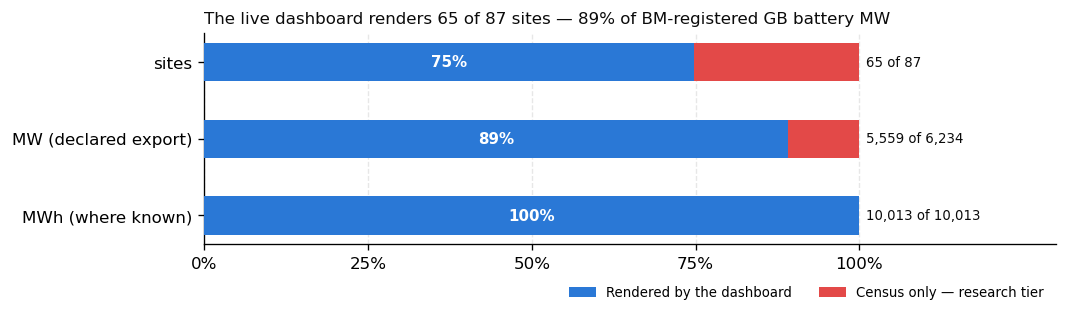

In [11]:
# Figure 4 — coverage on each basis, with the gap drawn as a real quantity
# rather than as absence.
fig, ax = plt.subplots(figsize=(9, 2.9))

bases = list(stats.index)
y = np.arange(len(bases))
total = stats["census"].to_numpy(dtype=float)
share = stats["dashboard"].to_numpy(dtype=float) / total

# Each basis is on its own scale (sites, MW, MWh), so bars are drawn as a share
# of their own total — the absolute figures are direct-labelled instead.
ax.barh(y, share, height=0.5, color=C["covered"], label="Rendered by the dashboard", zorder=3)
ax.barh(y, 1 - share, left=share, height=0.5, color=C["gap"],
        label="Census only — research tier", zorder=3)

for i in range(len(bases)):
    ax.text(share[i] / 2, i, f"{share[i]:.0%}", ha="center", va="center", color="white",
            fontsize=9, fontweight="bold", zorder=4)
    ax.text(1.01, i, f"{stats['dashboard'].iloc[i]:,.0f} of {total[i]:,.0f}", va="center",
            fontsize=8, color=C["ink"])

ax.set_yticks(y, bases)
ax.set_xlim(0, 1.30)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_title(
    f"The live dashboard renders {stats.loc['sites', 'dashboard']:.0f} of "
    f"{stats.loc['sites', 'census']:.0f} sites — "
    f"{stats.loc['MW (declared export)', 'dashboard_pct']:.0f}% of BM-registered GB battery MW",
    fontsize=10, loc="left", color=C["ink"])
ax.legend(frameon=False, fontsize=8, ncol=2, loc="lower right", bbox_to_anchor=(1.0, -0.32))
plt.tight_layout()
# Print-resolution export: coverage by site count, MW and MWh.
# Export name keeps the poster's own numbering, as above.
save_poster_fig(fig, "nb06_fig2_coverage_by_basis")

plt.show()


## 4. Characterising the gap — and the shortlist that closes it

A percentage without a direction invites exactly the criticism this section exists to answer.
The comparisons below say *which* assets the dashboard cannot show, which is what turns
"89% of MW" into a statement about which of its figures generalise and which do not.

The gap has a single cause and it is not curation effort: it is **published duration**. So it
falls wherever operators say least, which is the small distribution-connected tail. The last
two cells turn that into a work list — the sites whose MWh is worth researching, largest first,
and the operators whose whole estate is invisible for want of one number each.


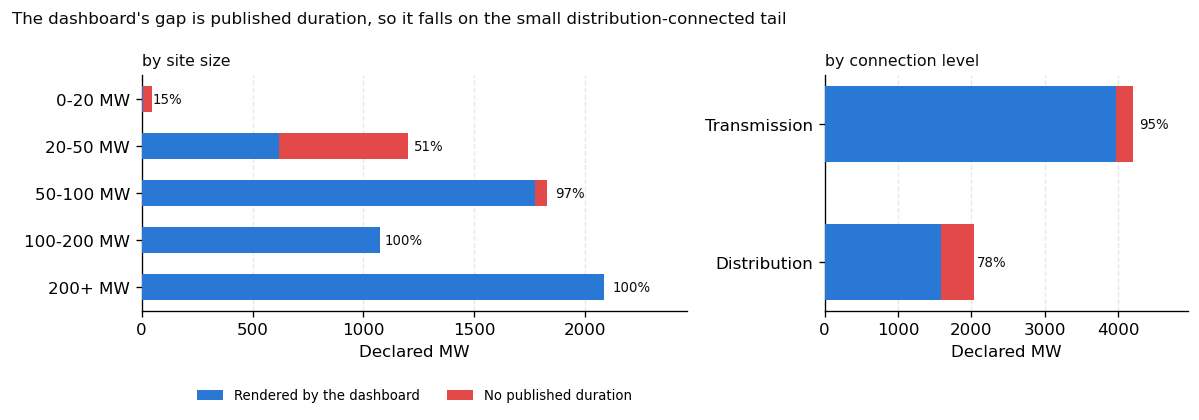

In [12]:
# Figure 5 — where the missing MW actually sits. Same two frames as figure 2,
# split by whether the dashboard can render the site: the population there, the
# coverage of it here, in the same hues as figure 4 so the two read as one.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), gridspec_kw={"width_ratios": [3, 2]})

for ax, frame, title in (
    (axes[0], by_size, "by site size"),
    (axes[1], by_conn, "by connection level"),
):
    y = np.arange(len(frame))
    shown_mw = frame["mw_in_dashboard"].to_numpy()
    gap_mw = (frame["mw"] - frame["mw_in_dashboard"]).to_numpy()
    ax.barh(y, shown_mw, height=0.55, color=C["covered"],
            label="Rendered by the dashboard", zorder=3)
    ax.barh(y, gap_mw, left=shown_mw, height=0.55, color=C["gap"],
            label="No published duration", zorder=3)
    for i, pct in enumerate(frame["dashboard_pct"]):
        ax.text(frame["mw"].iloc[i] * 1.02, i, f"{pct:.0f}%", va="center",
                fontsize=8, color=C["ink"])
    ax.set_yticks(y, frame.index)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("Declared MW")
    ax.set_xlim(0, frame["mw"].max() * 1.18)
    ax.set_title(title, fontsize=9.5, loc="left", color=C["ink"])

# Below the axes: inside the panel the legend lands on the 200+ MW bar.
axes[0].legend(frameon=False, fontsize=8, ncol=2, loc="upper center",
               bbox_to_anchor=(0.5, -0.28))
fig.suptitle(
    "The dashboard's gap is published duration, so it falls on the small "
    "distribution-connected tail",
    fontsize=10, x=0.005, ha="left", color=C["ink"])
plt.tight_layout()
# Print-resolution export: coverage gap by size band and connection level.
# Export name keeps the poster's own numbering, as above.
save_poster_fig(fig, "nb06_fig3_where_missing_mw_sits")

plt.show()


In [13]:
# The sites the dashboard cannot render, largest first — the shortlist for
# closing the gap. Each one needs a single number: a published energy capacity.
# Nothing else about them is missing; they are already BM-registered, already
# identified by the census, and already fetched by every research-tier call.
invisible = table[~table["in_dashboard"]].sort_values("declared_export_mw", ascending=False)
cols = ["site_name", "lead_party", "declared_export_mw", "n_bmus", "connection_level", "confidence"]
print(f"{len(invisible)} census sites have no published duration, totalling "
      f"{invisible['declared_export_mw'].sum():,.0f} MW "
      f"({100 * invisible['declared_export_mw'].sum() / census_mw:.1f}% of the census)\n")
invisible[cols].head(20).to_string(index=False)


22 census sites have no published duration, totalling 675 MW (10.8% of the census)



"                   site_name                     lead_party  declared_export_mw  n_bmus connection_level   confidence\n                   T_HRSTB-1     SP Renewables (UK) Limited              52.000       1     Transmission corroborated\n            Thame Road  BESS           Tesla Motors Limited              49.500       1     Distribution corroborated\n             Ilmer Lane BESS           Tesla Motors Limited              49.500       1     Distribution corroborated\nJamesfield 1 Battery Storage           Tesla Motors Limited              49.000       2     Distribution corroborated\n     Tollgate Energy Storage    Tollgate Energy Storage Ltd              49.000       1     Distribution corroborated\n    Nursling Battery Storage   EDF Energy Customers Limited              48.000       1     Transmission corroborated\n           Fiddler's Ferry 2      Keadby Generation Limited              41.000       3     Transmission corroborated\n         Pivot Power Kemsley   EDF Energy Custo

In [14]:
# Operators whose entire estate is invisible to the dashboard, ranked by the MW
# they run. These are the highest-value rows of the shortlist above: one
# published figure per operator brings a whole estate onto the page.
by_owner = table.groupby("lead_party").apply(
    lambda g: pd.Series({
        "sites": len(g),
        "mw": g["declared_export_mw"].sum(),
        "mw_shown": g.loc[g["in_dashboard"], "declared_export_mw"].sum(),
    }),
    include_groups=False,
)
invisible_owners = by_owner[by_owner["mw_shown"] == 0].sort_values("mw", ascending=False)
print(f"{len(invisible_owners)} operators have no site the dashboard can render, "
      f"together running {invisible_owners['mw'].sum():,.0f} MW across "
      f"{int(invisible_owners['sites'].sum())} sites\n")
invisible_owners.head(12)[["sites", "mw"]].to_string()


4 operators have no site the dashboard can render, together running 186 MW across 9 sites



'                             sites      mw\nlead_party                                \nConrad Energy (Trading) Ltd    4.0  72.664\nTollgate Energy Storage Ltd    1.0  49.000\nKeadby Generation Limited      3.0  43.000\nField Newport Ltd              1.0  20.933'

## 5. A persistent asset ID, and what stays outside it

Sites change owner, change name and change BM Unit registration. Keyed on any of those, one
asset silently becomes two across a multi-year window — which is precisely the window this
project analyses. `fleet.census` keys on the National Grid BMU root, which is tied to the
physical connection point rather than to the commercial arrangement around it, so a
re-contracted site stays one row. Roots that genuinely moved are stitched by an explicit alias
map rather than by fuzzy matching.

The cell below also sizes the honest limit of the whole exercise: the aggregator and supplier
portfolio units. They are real routes to market for real batteries, but they are portfolios,
not sites — no per-unit Physical Notification, no per-site cashflow — so they can be counted
as an unknown, never analysed.

In [15]:
multi = table[table["n_bmus"] > 1]
print(f"{len(multi)} of {len(table)} sites span more than one BM Unit "
      f"({int(multi['n_bmus'].sum())} units in total).")
print("Without a persistent asset ID each of those would count as several assets.\n")

# The portfolio tier: bidirectional supplier/VLP units, outside the site denominator.
portfolios = units[
    (units["bmUnitType"] == "S")
    & units["is_bidirectional"]
    & units["is_symmetric"]
]
print(f"Supplier/VLP portfolio units with a battery-like signature: {len(portfolios)}, "
      f"{portfolios['generationCapacity'].sum():,.0f} MW declared.")
print("Counted as an unknown above the census, never as sites.")

18 of 87 sites span more than one BM Unit (55 units in total).
Without a persistent asset ID each of those would count as several assets.

Supplier/VLP portfolio units with a battery-like signature: 72, 2,220 MW declared.
Counted as an unknown above the census, never as sites.


## 6. Robustness — does the answer depend on the threshold?

The symmetry band is the only tuned number in the identifying rule, so the coverage figure is
only as good as its insensitivity to it. If the answer moved materially between a tight band
and a loose one, it would be an artefact of the choice rather than a measurement.

In [16]:
base = units["is_physical"] & units["fuel_permits_battery"] & units["is_bidirectional"]
bands = [(0.90, 1.20), (0.85, 1.25), (0.80, 1.30), (0.75, 1.35), (0.70, 1.50), (0.60, 1.70), (0.50, 2.00)]

rows = []
registry_mw = table.loc[table["in_registry"], "declared_export_mw"].sum()
for lo, hi in bands:
    sel = base & units["capability_ratio"].between(lo, hi)
    # Named for the band, not the census: `census_mw` is the whole-census total
    # set in section 2, and rebinding it here silently corrupted section 8.
    band_mw = units.loc[sel, "generationCapacity"].sum()
    rows.append({
        "band": f"[{lo:.2f}, {hi:.2f}]",
        "units": int(sel.sum()),
        "census_mw": round(band_mw, 0),
        "coverage_pct": round(100 * registry_mw / band_mw, 1),
        "registry_recall": f"{int((sel & units['sig_registry']).sum())}/{len(known)}",
    })
sensitivity = pd.DataFrame(rows).set_index("band")
sensitivity

,units,census_mw,coverage_pct,registry_recall
band,,,,
"[0.90, 1.20]",126,6288.0,46.0,47/87
"[0.85, 1.25]",126,6288.0,46.0,47/87
"[0.80, 1.30]",126,6288.0,46.0,47/87
"[0.75, 1.35]",127,6348.0,45.5,47/87
"[0.70, 1.50]",130,6354.0,45.5,47/87
"[0.60, 1.70]",132,6354.0,45.5,47/87
"[0.50, 2.00]",133,6358.0,45.5,47/87


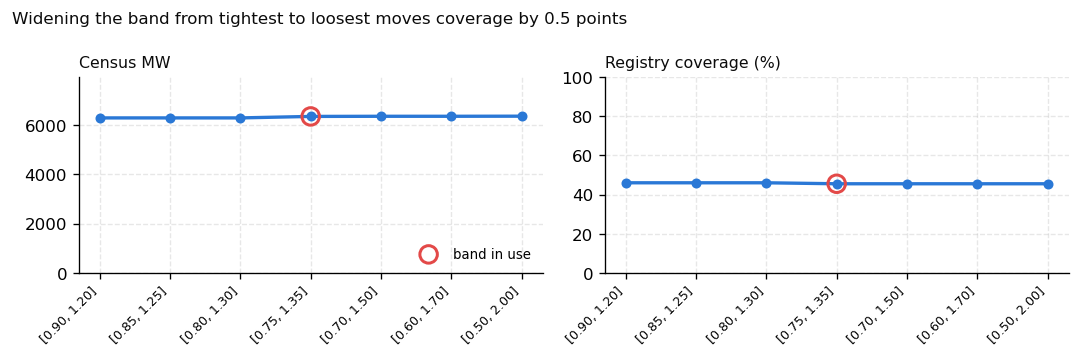

In [17]:
# Figure 6 — two panels, never two y-axes on one.
fig, axes = plt.subplots(1, 2, figsize=(9, 3.0), sharex=True)
x = np.arange(len(sensitivity))
selected = [i for i, b in enumerate(sensitivity.index)
            if b == f"[{census.SYMMETRY_BAND[0]:.2f}, {census.SYMMETRY_BAND[1]:.2f}]"]

# Both panels start at zero. The claim being made is that the result barely
# moves, and a truncated axis would manufacture a cliff out of a 1% change —
# arguing against the very point of the figure.
for i, (ax, column, label, top) in enumerate((
    (axes[0], "census_mw", "Census MW", sensitivity["census_mw"].max() * 1.25),
    (axes[1], "coverage_pct", "Registry coverage (%)", 100.0),
)):
    ax.plot(x, sensitivity[column], color=C["covered"], lw=2, marker="o", ms=5, zorder=3)
    if selected:
        ax.scatter(selected, sensitivity[column].iloc[selected], s=110, facecolor="none",
                   edgecolor=C["gap"], lw=1.8, zorder=4, label="band in use")
    ax.set_ylim(0, top)
    ax.set_xticks(x, sensitivity.index, rotation=45, ha="right", fontsize=7.5)
    ax.set_title(label, fontsize=9.5, loc="left", color=C["ink"])

axes[0].legend(frameon=False, fontsize=8, loc="lower right")
spread = sensitivity["coverage_pct"].max() - sensitivity["coverage_pct"].min()
fig.suptitle(f"Widening the band from tightest to loosest moves coverage by {spread:.1f} points",
             fontsize=10, x=0.005, ha="left", color=C["ink"])
plt.tight_layout()
plt.show()

## 7. The revenue stack we can and cannot see

Coverage of *assets* is one half of the question; coverage of *revenue* is the other. The live
dashboard prices two streams — the wholesale position at MID and Balancing Mechanism cashflows
through `EBOCF` — and for a GB battery that is knowingly incomplete. Frequency response and
reserve have historically been the dominant earner, so a site that looks unprofitable on
wholesale plus BM alone may simply be earning somewhere the analysis was not looking.

`fleet.ancillary` adds that third stream at site level. It joins without any fuzzy matching:
NESO's auction results name the winning unit by its National Grid BM Unit name — `KILSB-5`,
`CLAYB-1`, `THURB-3` — which is exactly the key `fleet.census` already uses.

**The history is fragmented, and that is the headline caveat.** NESO replaced its auction
platform repeatedly across this window and published per-unit results under five schemas with
real gaps between them. Two traps follow, and the cells below refuse both rather than paper over
them: a month with no data is *not* a month of zero revenue, and — more subtly — two months
that both have data are not comparable if they cover different **services**.

In [18]:
anc_cov = ancillary.coverage_by_month(ANALYSIS_START, ANALYSIS_END)
print(f"months with any per-unit ancillary data: {int(anc_cov['covered'].sum())} of {len(anc_cov)} "
      f"({100 * anc_cov['covered'].mean():.0f}%)\n")

missing_months = anc_cov[~anc_cov["covered"]]
print("Months NESO published no per-unit results for — these are gaps, not zeros:")
print("  " + ", ".join(missing_months.index) if len(missing_months) else "  none")

months with any per-unit ancillary data: 68 of 104 (65%)

Months NESO published no per-unit results for — these are gaps, not zeros:
  2018-01, 2018-02, 2018-03, 2018-04, 2018-05, 2018-06, 2018-07, 2018-08, 2018-09, 2018-10, 2018-11, 2018-12, 2019-01, 2019-02, 2019-03, 2019-04, 2019-05, 2019-06, 2019-07, 2019-08, 2019-09, 2019-10, 2019-11, 2020-05, 2020-06, 2020-07, 2020-08, 2020-09, 2021-10, 2023-12, 2024-01, 2024-02, 2025-11, 2025-12, 2026-01, 2026-02


In [19]:
# The only unit of legitimate comparison: contiguous months sharing a service set.
windows = ancillary.comparable_windows(anc_cov)
windows.assign(gbp_m=(windows["revenue_gbp"] / 1e6).round(2)).drop(columns="revenue_gbp")

,first_month,last_month,months,services,era,gbp_m
0,2019-12,2020-04,5,DLH,FFR Phase 2 (2019-12 → 2020-04),0.17
1,2020-10,2021-09,12,DC LF,Dynamic Containment masterdata (2020-10 → 2021...,59.85
2,2021-11,2022-03,5,"DCH, DCL",DC/DR/DM (2021-09 → 2023-11),25.19
3,2022-04,2022-04,1,"DCH, DCL, DRH, DRL",DC/DR/DM (2021-09 → 2023-11),9.53
4,2022-05,2023-11,19,"DCH, DCL, DMH, DML, DRH, DRL",DC/DR/DM (2021-09 → 2023-11),168.99
5,2024-03,2025-10,20,Balancing Reserve,Balancing Reserve (2024-03 → 2025-10),6.01
6,2026-03,2026-08,6,"Balancing Reserve, Quick Reserve, Response, Sl...",EAC Response/Reserve (2026-03 → present),53.12


The Balancing Reserve window is the trap made concrete. It looks complete — twenty consecutive months,
almost every day present — but it carries **only Balancing Reserve**, a minor product. Reading
its revenue against the DC/DR/DM window either side would show a collapse of over 90% that is
entirely an artefact of which auction NESO happened to publish per-unit. Any trend line drawn
across these three windows measures NESO's publishing history, not the market.

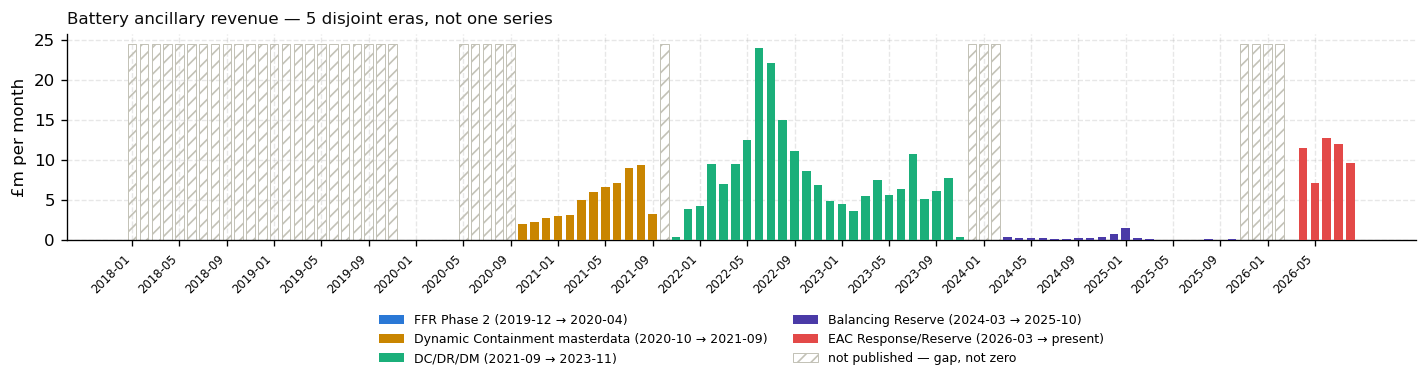

In [20]:
# Figure 7 — monthly ancillary revenue, with the gaps left as gaps.
monthly = anc_cov.copy()
monthly["gbp_m"] = monthly["revenue_gbp"] / 1e6

fig, ax = plt.subplots(figsize=(12, 3.6))
x = np.arange(len(monthly))

# One colour per era, so the eye cannot join them into a single trend. The
# order is fixed and validated for colour-vision separation rather than cycled;
# if NESO ever publishes a sixth per-unit era this should gain a hue chosen the
# same way, not wrap around and repaint an existing one.
ERA_HUES = ["#2a78d6", "#c98500", "#1baf7a", "#4a3aa7", "#e34948"]
era_order = [e for e in monthly["era"].dropna().unique()]
if len(era_order) > len(ERA_HUES):
    raise ValueError(
        f"{len(era_order)} eras but {len(ERA_HUES)} hues — add one, do not cycle"
    )
era_colour = dict(zip(era_order, ERA_HUES))
for era in era_order:
    mask = monthly["era"] == era
    ax.bar(x[mask.to_numpy()], monthly.loc[mask, "gbp_m"], width=0.72,
           color=era_colour[era], label=era, zorder=3)

# Gap months are drawn as hatched ground, never as a zero bar.
gap_mask = (~monthly["covered"]).to_numpy()
if gap_mask.any():
    ax.bar(x[gap_mask], np.full(gap_mask.sum(), monthly["gbp_m"].max() * 1.02),
           width=0.72, color="none", edgecolor=C["ghost"], hatch="///",
           linewidth=0.6, label="not published — gap, not zero", zorder=2)

step = max(1, len(monthly) // 24)
ax.set_xticks(x[::step], monthly.index[::step], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("£m per month")
ax.set_title(f"Battery ancillary revenue — {len(era_order)} disjoint eras, not one series",
             fontsize=10, loc="left", color=C["ink"])
ax.legend(frameon=False, fontsize=7.5, loc="upper center", bbox_to_anchor=(0.5, -0.30), ncol=2)
plt.tight_layout()
plt.show()

### How much of that revenue reaches a site

The same aggregator problem that limits the asset census limits the revenue view. A unit
trading as `AG-GBL0EN` or `HAB-15` is a portfolio, not a site — its earnings are real but
cannot be attributed to an asset without inventing a mapping. They are reported here rather
than dropped, so the fleet total and the sum of its named sites never silently disagree.

In [21]:
attribution = ancillary.unmatched_summary()
attribution.assign(
    attributed_gbp_m=(attribution["attributed_gbp"] / 1e6).round(2),
    unattributed_gbp_m=(attribution["unattributed_gbp"] / 1e6).round(2),
)[["attributed_gbp_m", "unattributed_gbp_m", "attributed_pct"]]

,attributed_gbp_m,unattributed_gbp_m,attributed_pct
era,,,
Balancing Reserve (2024-03 → 2025-10),5.67,0.34,94.4
DC/DR/DM (2021-09 → 2023-11),122.10,81.61,59.9
Dynamic Containment masterdata (2020-10 → 2021-09),13.30,0.00,100.0
EAC Response/Reserve (2026-03 → present),25.65,27.47,48.3


In [22]:
# Ancillary earnings by site over the most recent comparable window only — the
# one carrying the full service stack. Earlier windows are a different product
# mix and must not be pooled with it.
recent = windows.iloc[-1]
window_start = pd.Period(recent["first_month"]).start_time.date()

stack = ancillary.with_census()
stack = stack[stack["date"] >= window_start]

# `unit_class` says what each winning unit actually is. Only one of the four
# is a physical site, and it is not the largest.
by_class = (stack.groupby("unit_class")["revenue_gbp"].sum() / 1e6).round(2)
print(f"Ancillary earnings, {recent['first_month']} → {recent['last_month']}")
print(f"services: {recent['services']}")
print(f"total £{stack['revenue_gbp'].sum() / 1e6:.1f}m\n")
print((by_class.sort_values(ascending=False).to_frame("£m")
       .assign(share=(100 * by_class / by_class.sum()).round(1))).to_string())

Ancillary earnings, 2026-03 → 2026-08
services: Balancing Reserve, Quick Reserve, Response, Slow Reserve
total £53.1m

                         £m  share
unit_class                        
aggregator portfolio  27.47   51.7
census site           13.69   25.8
VLP / supplier unit    8.87   16.7
unknown                3.10    5.8


In [23]:
# The sites themselves, within the only class that is one.
sites_only = stack[stack["unit_class"] == "census site"]
by_site = (sites_only.groupby(["site_name", "in_registry"], dropna=False)["revenue_gbp"]
                     .sum().sort_values(ascending=False).reset_index())
by_site["gbp_k"] = (by_site["revenue_gbp"] / 1e3).round(0)
print(f"{len(by_site)} census sites earned ancillary revenue in this window; "
      f"{int(by_site['in_registry'].sum())} of them are in the curated registry\n")
by_site.head(15)[["site_name", "in_registry", "gbp_k"]].to_string(index=False)

65 census sites earned ancillary revenue in this window; 17 of them are in the curated registry



'                  site_name  in_registry  gbp_k\n                  T_PINFB-1         True 1327.0\n  Richborough Energy Park 1         True 1141.0\n                  T_THURB-1        False  820.0\n   Burwell Weirs Drove BESS         True  786.0\n                Wishaw BESS         True  714.0\nPillswood 1 Battery Storage         True  697.0\n         Whitelee 1 Battery         True  647.0\n             Roosecote BESS         True  624.0\n             Brentwood BESS        False  611.0\n    Tollgate Energy Storage        False  580.0\n           Newton wood BESS        False  530.0\n   Nursling Battery Storage        False  528.0\n  Hunningley Stairfoot BESS        False  451.0\n            Brook Farm BESS        False  450.0\n              Berkeley BESS        False  410.0'

Only about a quarter of recent battery ancillary revenue lands on a physical BM-registered
site. Aggregator portfolios take roughly half, and VLP or supplier routes most of the rest.
This is the same finding as the asset census reached from the other direction: the part of the
GB battery fleet that can be analysed per site is a minority of the whole, and the aggregator
tier — invisible to every per-unit feed this project can reach — is where a large share of the
activity and the earnings actually sit.

## 8. The claim

One sentence, and it is what any figure quoted from the **live dashboard** should be read
beside. It is deliberately less comfortable than the number one would hope for, and it is the
one that survives scrutiny.


In [24]:
# Assembled here rather than in `fleet.coverage`, whose `headline_claim` speaks
# for `fleet.curated` — the metadata table, which nothing is reported on.
dash_mw = table.loc[table["in_dashboard"], "declared_export_mw"].sum()
total_census_mw = table["declared_export_mw"].sum()
weakest = by_size[by_size["mw"] > 0].sort_values("dashboard_pct").head(2)

print(
    f"The live dashboard renders {int(table['in_dashboard'].sum())} of {len(table)} "
    f"BM-registered GB battery sites, {100 * dash_mw / total_census_mw:.1f}% of their declared MW. "
    f"It under-represents {' and '.join(str(i) for i in weakest.index)} assets, because it can "
    f"only show a site whose energy capacity someone publishes. Batteries traded behind "
    f"aggregator, VLP or supplier portfolios have no per-unit settlement data and are outside "
    f"this denominator entirely."
)


The live dashboard renders 65 of 87 BM-registered GB battery sites, 89.2% of their declared MW. It under-represents 0-20 MW and 20-50 MW assets, because it can only show a site whose energy capacity someone publishes. Batteries traded behind aggregator, VLP or supplier portfolios have no per-unit settlement data and are outside this denominator entirely.


### What this changes

**For the research tier — notebooks 04 and 05.** They run on the census, so no coverage figure
here is a discount on their results: inside the BM-registered fleet they have the population
rather than a sample of it. What limits them is stated above and is not a percentage. Energy
capacity is known for 65 of 87 sites, so anything divided by MWh is reported over that subset;
metadata is machine-derived for most sites, so optimiser is the BM Unit's lead party and region
its GSP group rather than a hand-checked value; and the aggregator tier sits outside the
denominator entirely.

**For the presentation tier — the live dashboard.** Its 65 sites are 89% of BM-registered
battery MW: complete above 100 MW, 97% of the 50–100 MW band, but 51% of 20–50 MW and 15% below
20 MW, and 95% of transmission-connected MW against 78% of distribution-connected. Its figures
describe the BM-registered fleet with a stated tail exclusion, rather than describing its big
end and being read as the whole.

**Why it stops at 65 rather than 87, and how to close that.** Not curation effort — published
duration. Cycles per day and the duration bucket both divide by energy capacity, and 22 census
sites (675 MW) have none published, so showing them would render blank cells rather than
smaller numbers. Every one of those sites is already BM-registered, already identified, already
fetched by the research tier; each needs exactly one researched number, and section 4 ranks
them by how much MW that number would bring onto the page.

**What no tier can see.** Batteries traded behind an aggregator, VLP or supplier portfolio have
no per-unit feed at all — no Physical Notification, no per-site cashflow — and section 7 finds
that is where roughly half of recent battery ancillary revenue lands. That, rather than any
coverage gap measured here, is the binding limit on any claim about GB storage as a whole.


## How other markets price duration and scarcity delivery

Reference material, not computation — checked August 2026. It exists because the
poster makes a policy claim, and a claim about market design should be sourced
the same way a number is.

**Read this against what the analysis actually measures.** The Capacity Market
enters this project in three separate roles and only two of them are analysis:

| Role | Where | What it is |
|---|---|---|
| Capacity Market Notice as a stress signal | `live.resilience.cmn_flags`, notebook 05 | Boolean: did the operator declare a tight margin in this period. **13 periods in eight years.** This is adequacy stress, not resilience — which is why the poster says *scarcity* |
| CM register as an energy-capacity source | `fleet.coverage`, this notebook | 18 sites' MWh, carrying the de-rating caveat (about a third duration understatement) |
| CM as a policy mechanism | poster only | De-rating factors and stress-event delivery obligations. **Never analysed here** — cited, not measured |

### Great Britain already procures duration, in three ways

| Mechanism | Status | What it prices |
|---|---|---|
| CM duration de-rating | Live since 2017 | 0.5 h ≈ 4–5% of nameplate, rising to ≈95% at 8 h and above |
| CM stress-event obligation | Live | Delivery *inside a declared System Stress Event*: under-delivery is penalised, over-delivery is paid from the penalty pot |
| LDES cap and floor | Window 1 decided 26 June 2026 | 16 projects, 7.6 GW at 8–22 h, from 171 applications (77 eligible, 27 GW) |

This matters for how the result is framed. GB has *not* ignored duration — as of
two months ago it committed 7.6 GW of 8–22 hour storage. The evidence here
supports what GB has just done rather than proposing something new.

It also disciplines the claim about delivery. GB does pay for delivered scarcity
energy — but only inside a declared stress event, and this study counts 13 such
periods in eight years. Everything measured here (top-decile residual load, DRM
percentiles, LoLP) happens in tight-but-*undeclared* periods, where no delivery
obligation exists at all. That is the gap, and it is narrower and more defensible
than "nothing pays for delivery".

For calibration: the CM's own work puts mean stress-event duration near two hours
with most under four. The event analysis in notebook 05 finds a median of 3.0 h
across 418 events, with a tail to 16.5 h.

### Elsewhere in Europe, sorted by what the instrument actually buys

**Duration procurement.** Italy's MACSE is the purest case in Europe: Terna
procures storage denominated in *energy*, not power. The first auction (30
September 2025) secured 10 GWh on 15-year contracts from 2028, oversubscribed
more than four times, clearing at €12,959/MWh-year against a €37,000 reserve.

**Timing and location.** France's TURPE 7 is an optional locational and temporal
network tariff, live from August 2026 with a 12-month commitment. Up to €69/MWh
bonus for charging in solar-heavy injection zones and up to €76/MWh penalty for
discharging there; injection is rewarded in demand zones during winter peaks,
weekdays December to February, 09:00–11:00 and 18:00–20:00.

**Cost allocation, not scarcity.** Germany exempts storage commissioned before
4 August 2029 from grid charges for 20 years (§118(6) EnWG). BNetzA confirmed in
May 2026 that the exemption expires as planned rather than early, to be replaced
by a moderate capacity-based charge; the AgNeS decision is due late 2026.

**EU level.** The 2024 Market Design Reform (Regulation (EU) 2024/1747) created
Non-Fossil Flexibility Support Schemes and made capacity mechanisms structural
rather than a last resort. Spain's €9bn scheme (€900m a year for ten years from
May 2026) is open to storage.

### What survives the comparison

Duration procurement is well covered — GB LDES, GB CM de-rating, Italy MACSE.
Timing and location are well covered — France TURPE 7, German capacity charges,
scarcity pricing generally. **Sustained delivery in tight-but-undeclared periods
is covered nowhere**, including GB. That is the contribution this study makes,
and it is the one line that survives contact with every mechanism checked.

France is the clean natural experiment. TURPE 7 sharpens precisely the timing
signal the frontier here says is close to exhausted, so this study predicts it
moves scarcity alignment little; Italy's MACSE and GB's LDES move the ceiling the
duration sweep says is binding. A large scarcity-alignment improvement in TURPE
7's first winter would weaken the duration thesis. Its absence would corroborate
it — through an experiment nobody here had to run.

### Sources

- Ofgem, LDES cap and floor Window 1 decision — https://www.ofgem.gov.uk/press-release/ofgem-boosts-long-duration-storage-secure-more-homegrown-energy-customers
- Energy-Storage.News, LDES Window 1 winners — https://www.energy-storage.news/uks-ofgem-goes-big-on-ldes-cap-and-floor-window-1-18-hour-lithium-ion-among-winners/
- EMRS G18, Capacity Market Stress Event Guide — https://www.emrsettlement.co.uk/document/guidance/g18-capacity-market-stress-event-guide/
- EMRS G17, Capacity Provider Payments — https://www.emrsettlement.co.uk/document/guidance/g17-capacity-provider-payments/
- NESO, storage de-rating factors methodology consultation — https://www.emrdeliverybody.com/Capacity%20Markets%20Document%20Library/ESO-Storage-De-rating-Factors-Consultation-2024-V1.pdf
- Terna, first MACSE auction result — https://download.terna.it/terna/Terna_completed_first_MACSE_auction_8de00ea13c11e89.pdf
- Energy-Storage.News, MACSE auction — https://www.energy-storage.news/italys-exceptionally-competitive-first-macse-energy-storage-auction-concludes-procuring-10gwh/
- Modo Energy, TURPE 7 explained — https://modoenergy.com/research/en/france-grid-tariff-fee-battery-turpe
- pv magazine, France grid tariff revision — https://www.pv-magazine.com/2025/10/10/france-revises-grid-tariffs-to-spur-smarter-battery-storage-use/
- HSF Kramer, German grid fee reform — https://www.hsfkramer.com/notes/energy/2026-posts/german-grid-fee-reform-for-bess-bnetza-preserves-grand-fathering-protection-and-unveils-future-framework
- European Commission, electricity market design — https://energy.ec.europa.eu/topics/markets-and-consumers/electricity-market-design_en
- Energy-Storage.News, Spain capacity market approval — https://www.energy-storage.news/eu-approves-spain-euro-9-billion-capacity-market-generation-demand-response-energy-storage/


In [25]:
# Poster numbers, published rather than retyped.
#
# `reports/poster/poster.typ` reads this file. Every figure the poster shows
# from this notebook is written here once, so the board and the notebook cannot
# disagree — which is exactly how they drifted before, silently, whenever a
# register refreshed or a window moved.
import json

from src.utils.poster import save_poster_metrics

_mwh_src = table["mwh_source"].value_counts()
_dist = by_conn.loc["Distribution"]
_top = by_size.iloc[-1]

nb06_metrics = {
    "snapshot": census.SNAPSHOT.strftime("%-d %B %Y"),
    "census_sites": f"{len(table)} sites",
    "census_bmus": f"{int(table['n_units'].sum())} BM Units",
    "census_mw": f"{table['declared_export_mw'].sum():,.0f} MW",
    "mwh_hand": f"{int(_mwh_src.get('corporate', 0))} sites",
    "mwh_cm": f"{int(_mwh_src.get('capacity_market', 0))}",
    "mwh_none": f"{int(table['capacity_mwh'].isna().sum())}",
    "curated_bmus": f"{len(curated_units)}",
    "curated_recovered": f"{len(recovered)}",
    "top_band_sites": f"{int(_top['sites'])}",
    "top_band_share": f"{100 * _top['mw'] / census_mw:.0f}%",
    "dist_sites": f"{int(_dist['sites'])}",
    "dist_share": f"{100 * _dist['mw'] / census_mw:.0f}%",
}
print(json.dumps(nb06_metrics, indent=2))
save_poster_metrics("nb06", nb06_metrics)


{
  "snapshot": "24 August 2026",
  "census_sites": "87 sites",
  "census_bmus": "124 BM Units",
  "census_mw": "6,234 MW",
  "mwh_hand": "24 sites",
  "mwh_cm": "18",
  "mwh_none": "22",
  "curated_bmus": "47",
  "curated_recovered": "47",
  "top_band_sites": "7",
  "top_band_share": "33%",
  "dist_sites": "44",
  "dist_share": "33%"
}


PosixPath('/Users/abhinav/Documents/code/power-trading/reports/figures/poster/nb06_metrics.json')